# Week 4 Lab: CRS, Projections, and Mapping in Python
## ESCI 3515: Geospatial Artificial Intelligence

---

**This week we tackle one of the most common GIS mistakes: coordinate reference system mismatches.**

When you combine two spatial layers that use different coordinate systems, your map will look wrong — or your spatial analysis will produce completely incorrect results. This is not a rare edge case: it happens in almost every real-world GIS project that pulls data from multiple sources.

**Goal for this notebook:**
By the end of this lab, you will be able to:
- Explain the difference between geographic and projected coordinate systems
- Detect a CRS mismatch between two layers
- Reproject a layer to a new CRS using `.to_crs()`
- Produce a clean static map with two layers overlaid
- Build a basic interactive web map using Folium

**How to use this notebook:**
1. Read each markdown explanation before running the code.
2. Run cells in order with **Shift + Enter**.
3. Cells marked `# TODO` are yours to complete.
4. Estimated time: 75–100 minutes

---
*ESCI 3515 | Module 2 | Week 4*

## Part 1: What is a Coordinate Reference System (CRS)?

A **Coordinate Reference System** is the mathematical rulebook that translates numbers (like `35.15, -90.04`) into real locations on the surface of the Earth.

Without a CRS, a pair of numbers is meaningless — is `(35.15, -90.04)` in degrees? In meters? Relative to what origin?

---

### Geographic CRS (unprojected)
- Coordinates are expressed in **degrees of latitude and longitude**
- The most common is **WGS84**, identified by EPSG code **4326**
- Used by GPS devices, Google Maps, most downloaded datasets
- **Units: degrees** (not a linear unit like meters or feet)
- Problem: degrees are not equal-length everywhere on Earth, so distance calculations can be inaccurate

```
Example: Memphis City Hall ≈ (35.1495° N, 90.0490° W)
In EPSG:4326 format: POINT(-90.0490, 35.1495)
```

---

### Projected CRS
- Coordinates are expressed in **linear units (meters or feet)** on a flat 2D surface
- The Earth is "projected" onto a flat plane using a mathematical formula
- Useful for **distance, area, and buffer calculations**
- Common examples for Memphis:

| EPSG Code | Name | Units | Best used for |
|-----------|------|-------|---------------|
| 3857 | Web Mercator | meters | Web tile maps (Google Maps, OpenStreetMap) |
| 3089 | TN State Plane South | **feet** | Local Tennessee analysis |
| 32616 | UTM Zone 16N | meters | Regional analysis (Memphis sits in Zone 16N) |

---

> **Rule of thumb:** Use **EPSG:4326** when loading data or sharing files. Use **EPSG:3089** (or UTM Zone 16N) when calculating distances, areas, or buffers in the Memphis region.

In [1]:
# Cell 3: Import required libraries
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point, box
import warnings
warnings.filterwarnings("ignore")  # suppress minor projection warnings for clean output

print("Libraries loaded:")
print(f"  GeoPandas : {gpd.__version__}")
print(f"  Pandas    : {pd.__version__}")
print(f"  Matplotlib: {plt.matplotlib.__version__}")

Libraries loaded:
  GeoPandas : 1.1.4
  Pandas    : 2.2.3
  Matplotlib: 3.10.0


In [2]:
# Cell 4: Create two GeoDataFrames with DIFFERENT coordinate reference systems.
# This simulates a common real-world situation: you download two datasets
# from different sources, and they use different CRS.

# --- Layer A: 5 Memphis points in EPSG:4326 (geographic, degrees) ---
layer_a_data = {
    "name": [
        "Memphis City Hall",
        "Beale Street",
        "Mud Island River Park",
        "AutoZone Park",
        "National Civil Rights Museum"
    ],
    "category": ["government", "entertainment", "park", "sports", "museum"],
    "lat": [35.1495, 35.1393, 35.1569, 35.1448, 35.1378],
    "lon": [-90.0490, -90.0490, -90.0609, -90.0530, -90.0579]
}
layer_a = gpd.GeoDataFrame(
    layer_a_data,
    geometry=gpd.points_from_xy(layer_a_data["lon"], layer_a_data["lat"]),
    crs="EPSG:4326"
)

# --- Layer B: 3 Memphis points in EPSG:3089 (Tennessee State Plane South, feet) ---
# To simulate this, we create points in geographic coordinates first,
# then reproject — just as a real projected dataset would arrive.
layer_b_data = {
    "name": ["FedExForum", "Shelby County Courthouse", "Memphis Zoo"],
    "category": ["sports", "government", "attraction"],
    "lat": [35.1491, 35.1476, 35.1489],
    "lon": [-90.0516, -90.0465, -89.9891]
}
layer_b_temp = gpd.GeoDataFrame(
    layer_b_data,
    geometry=gpd.points_from_xy(layer_b_data["lon"], layer_b_data["lat"]),
    crs="EPSG:4326"
)
layer_b = layer_b_temp.to_crs(epsg=3089)  # Now layer_b is in Tennessee State Plane (feet)

# Inspect both layers
print("=== LAYER A (EPSG:4326 — geographic, degrees) ===")
print(f"CRS: {layer_a.crs}")
print(layer_a[["name", "category", "geometry"]])
print()
print("=== LAYER B (EPSG:3089 — TN State Plane, feet) ===")
print(f"CRS: {layer_b.crs}")
print(layer_b[["name", "category", "geometry"]])

=== LAYER A (EPSG:4326 — geographic, degrees) ===
CRS: EPSG:4326
                           name       category                  geometry
0             Memphis City Hall     government   POINT (-90.049 35.1495)
1                  Beale Street  entertainment   POINT (-90.049 35.1393)
2         Mud Island River Park           park  POINT (-90.0609 35.1569)
3                 AutoZone Park         sports   POINT (-90.053 35.1448)
4  National Civil Rights Museum         museum  POINT (-90.0579 35.1378)

=== LAYER B (EPSG:3089 — TN State Plane, feet) ===
CRS: EPSG:3089
                       name    category                         geometry
0                FedExForum      sports  POINT (3634400.389 2879147.655)
1  Shelby County Courthouse  government  POINT (3635899.852 2878531.412)
2               Memphis Zoo  attraction  POINT (3653081.376 2878219.277)


## Part 2: Detecting CRS Mismatch

Now we have two layers about Memphis landmarks — but they use different coordinate systems.

**Why does this matter?**

Imagine you are told: "The library is at coordinates (500000, 200000)." Without knowing the coordinate system, you have no idea where that is. Is it 500,000 degrees? 500,000 meters east of some origin? 500,000 feet?

When two GeoDataFrames use different CRS:
- Their coordinate numbers are in completely different units and origins
- Plotting them together will show them in the wrong locations relative to each other
- Spatial operations (intersection, buffer, distance) will give wrong answers — or raise errors

**The fix:** Always check that your layers match before any analysis, and reproject one (or both) to a common CRS.

In [3]:
# Cell 6: Detect the CRS mismatch between layer_a and layer_b

print("=== CRS COMPARISON ===")
print(f"Layer A CRS: {layer_a.crs}")
print(f"Layer B CRS: {layer_b.crs}")
print()

# Boolean check: do the CRS match?
if layer_a.crs == layer_b.crs:
    print("CRS match: layers are compatible.")
else:
    print("*** CRS MISMATCH — layers are in different coordinate systems! ***")
    print("You must reproject before combining these layers.")
print()

# Demonstrate the problem: what do the coordinates look like?
print("Layer A sample coordinates (degrees):")
for _, row in layer_a.head(2).iterrows():
    print(f"  {row['name']}: ({row.geometry.x:.4f}, {row.geometry.y:.4f})")

print()
print("Layer B sample coordinates (feet — Tennessee State Plane):")
for _, row in layer_b.head(2).iterrows():
    print(f"  {row['name']}: ({row.geometry.x:,.0f}, {row.geometry.y:,.0f})")

print()
print("Notice: Layer B coordinates are in the millions of feet — very different from degrees!")
print("If we tried to overlay these, Layer B would appear far outside the map extent of Layer A.")

=== CRS COMPARISON ===
Layer A CRS: EPSG:4326
Layer B CRS: EPSG:3089

*** CRS MISMATCH — layers are in different coordinate systems! ***
You must reproject before combining these layers.

Layer A sample coordinates (degrees):
  Memphis City Hall: (-90.0490, 35.1495)
  Beale Street: (-90.0490, 35.1393)

Layer B sample coordinates (feet — Tennessee State Plane):
  FedExForum: (3,634,400, 2,879,148)
  Shelby County Courthouse: (3,635,900, 2,878,531)

Notice: Layer B coordinates are in the millions of feet — very different from degrees!
If we tried to overlay these, Layer B would appear far outside the map extent of Layer A.


## Part 3: Reprojecting Data

The solution to a CRS mismatch is **reprojection**: mathematically transforming the coordinates from one CRS to another.

In GeoPandas, this is done with the `.to_crs()` method:

```python
# Reproject to a new CRS using its EPSG code:
new_gdf = old_gdf.to_crs(epsg=4326)

# Or using a full CRS string:
new_gdf = old_gdf.to_crs("EPSG:3089")
```

**Key points:**
- `.to_crs()` returns a **new** GeoDataFrame — it does not modify the original
- Always store the result in a variable (e.g., `layer_b_wgs = layer_b.to_crs(epsg=4326)`)
- After reprojecting, verify the new CRS by printing `.crs`
- The attribute columns (name, category, etc.) are unchanged — only the geometry coordinates change

**Which CRS should you reproject to?**
- For visualization: reproject everything to **EPSG:4326** (degrees) — universal and easy
- For distance/area calculations in Memphis: reproject to **EPSG:3089** (feet) or **EPSG:32616** (meters)

In [4]:
# Cell 8: Reproject both layers to EPSG:4326 (WGS84 — geographic, degrees)
# This gives us a common CRS so we can overlay the layers.

layer_a_wgs = layer_a.to_crs(epsg=4326)   # Already in 4326, but this is explicit
layer_b_wgs = layer_b.to_crs(epsg=4326)   # Reproject from 3089 to 4326

print("After reprojection to EPSG:4326:")
print(f"  Layer A CRS: {layer_a_wgs.crs}")
print(f"  Layer B CRS: {layer_b_wgs.crs}")
print()

# Confirm they now match
if layer_a_wgs.crs == layer_b_wgs.crs:
    print("SUCCESS: CRS now match! Layers can be combined safely.")
else:
    print("ERROR: CRS still do not match — check your code.")

print()
print("Layer B coordinates after reprojection (now back in degrees):")
for _, row in layer_b_wgs.iterrows():
    print(f"  {row['name']}: ({row.geometry.x:.4f}, {row.geometry.y:.4f})")

After reprojection to EPSG:4326:
  Layer A CRS: EPSG:4326
  Layer B CRS: EPSG:4326

SUCCESS: CRS now match! Layers can be combined safely.

Layer B coordinates after reprojection (now back in degrees):
  FedExForum: (-90.0516, 35.1491)
  Shelby County Courthouse: (-90.0465, 35.1476)
  Memphis Zoo: (-89.9891, 35.1489)


In [5]:
# Cell 9: Also demonstrate reprojection to Tennessee State Plane (EPSG:3089)
# This is what you would use for distance and area calculations in Memphis.

layer_a_sp = layer_a.to_crs(epsg=3089)

print("Layer A reprojected to EPSG:3089 (TN State Plane South, feet):")
print(f"  CRS: {layer_a_sp.crs}")
print()

print("Comparing coordinate values for the same features:")
print(f"{'Name':<30} {'EPSG:4326 (degrees)':<30} {'EPSG:3089 (feet)'}")
print("-" * 85)
for i in range(len(layer_a)):
    pt_geo = layer_a.iloc[i].geometry
    pt_sp  = layer_a_sp.iloc[i].geometry
    name   = layer_a.iloc[i]["name"]
    print(f"{name:<30} ({pt_geo.x:.4f}, {pt_geo.y:.4f}){'':>5} ({pt_sp.x:>12,.0f}, {pt_sp.y:>12,.0f})")

print()
print("The State Plane coordinates are in FEET from the Tennessee State Plane origin.")
print("For Memphis: roughly 2.5 million feet east, 500 thousand feet north of the origin.")

Layer A reprojected to EPSG:3089 (TN State Plane South, feet):
  CRS: EPSG:3089

Comparing coordinate values for the same features:
Name                           EPSG:4326 (degrees)            EPSG:3089 (feet)
-------------------------------------------------------------------------------------
Memphis City Hall              (-90.0490, 35.1495)      (   3,635,184,    2,879,257)
Beale Street                   (-90.0490, 35.1393)      (   3,635,013,    2,875,545)
Mud Island River Park          (-90.0609, 35.1569)      (   3,631,751,    2,882,115)
AutoZone Park                  (-90.0530, 35.1448)      (   3,633,910,    2,877,602)
National Civil Rights Museum   (-90.0579, 35.1378)      (   3,632,327,    2,875,122)

The State Plane coordinates are in FEET from the Tennessee State Plane origin.
For Memphis: roughly 2.5 million feet east, 500 thousand feet north of the origin.


## Part 4: Making a Static Map

Now that our layers share a common CRS, we can overlay them on a single map.

**Approach:**
1. Create a figure and axes with `fig, ax = plt.subplots()`
2. Plot each layer onto the **same** `ax` object
3. Use different colors, markers, and labels to distinguish layers
4. Add a title, axis labels, legend, and a north arrow annotation

**Tip — adding a "north arrow":**
Matplotlib does not have a built-in north arrow, but you can fake one with `ax.annotate()`:

```python
ax.annotate("N", xy=(0.05, 0.95), xycoords="axes fraction",
            fontsize=14, ha="center", va="center",
            arrowprops=dict(facecolor="black", width=4, headwidth=12),
            xytext=(0.05, 0.87))
```

This places a text annotation and arrow in the upper-left corner of the map axes.

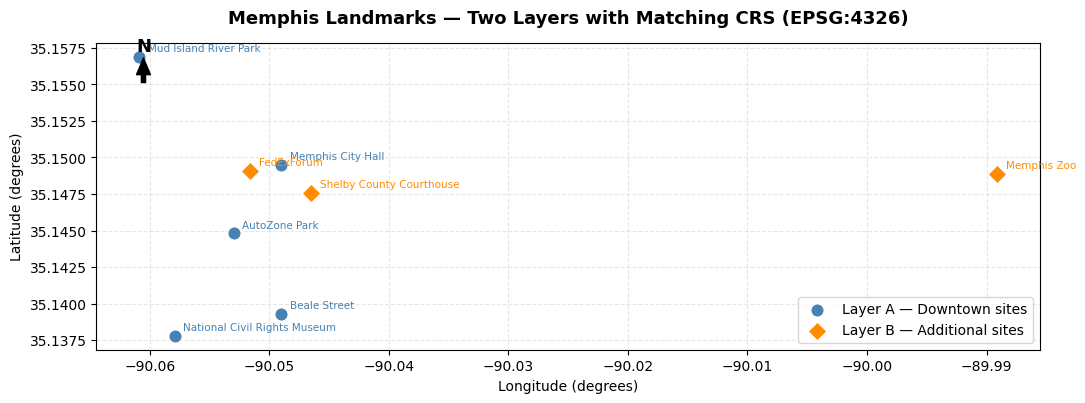

Static map rendered successfully.


In [6]:
# Cell 11: Create a static map with both layers overlaid
fig, ax = plt.subplots(figsize=(11, 9))

# Plot Layer A (government/entertainment/park/sports/museum) in blue
layer_a_wgs.plot(
    ax=ax,
    color="steelblue",
    markersize=90,
    edgecolor="white",
    linewidth=0.8,
    label="Layer A — Downtown sites",
    zorder=3
)

# Plot Layer B (sports/government/attraction) in orange
layer_b_wgs.plot(
    ax=ax,
    color="darkorange",
    markersize=90,
    marker="D",       # diamond shape to distinguish from Layer A circles
    edgecolor="white",
    linewidth=0.8,
    label="Layer B — Additional sites",
    zorder=4
)

# Annotate each point with its name
for _, row in layer_a_wgs.iterrows():
    ax.annotate(
        row["name"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 4), textcoords="offset points",
        fontsize=7.5, color="steelblue"
    )
for _, row in layer_b_wgs.iterrows():
    ax.annotate(
        row["name"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 4), textcoords="offset points",
        fontsize=7.5, color="darkorange"
    )

# North arrow
ax.annotate(
    "", xy=(0.05, 0.95), xycoords="axes fraction",
    xytext=(0.05, 0.87), textcoords="axes fraction",
    arrowprops=dict(facecolor="black", width=3, headwidth=10)
)
ax.text(0.05, 0.96, "N", transform=ax.transAxes,
        ha="center", va="bottom", fontsize=13, fontweight="bold")

# Map formatting
ax.set_title("Memphis Landmarks — Two Layers with Matching CRS (EPSG:4326)",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Longitude (degrees)", fontsize=10)
ax.set_ylabel("Latitude (degrees)", fontsize=10)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()
print("Static map rendered successfully.")

In [7]:
# Cell 12: TODO — Reprojection Practice
# A new layer (layer_c) has been created below in UTM Zone 16N (EPSG:32616).
# Your task: reproject layer_c to EPSG:4326 and verify it worked.

# Here is layer_c (already created for you):
layer_c_data = {
    "name": ["Memphis International Airport", "Graceland", "Libertyland Area"],
    "category": ["transportation", "attraction", "park"],
    "lat": [35.0424, 35.0479, 35.1009],
    "lon": [-89.9766, -90.0236, -89.9671]
}
layer_c_temp = gpd.GeoDataFrame(
    layer_c_data,
    geometry=gpd.points_from_xy(layer_c_data["lon"], layer_c_data["lat"]),
    crs="EPSG:4326"
)
layer_c = layer_c_temp.to_crs(epsg=32616)   # UTM Zone 16N, meters

print("layer_c is currently in:")
print(f"  CRS: {layer_c.crs}")
print()

# TODO: Reproject layer_c to EPSG:4326 and store it as layer_c_wgs
# YOUR CODE HERE:
layer_c_wgs = layer_c.to_crs(epsg=4326)

# TODO: Print the new CRS and confirm it matches EPSG:4326
print("After reprojection:")
print(f"  New CRS: {layer_c_wgs.crs}")
print()

# TODO: Print the first two rows of layer_c_wgs to see the coordinates in degrees
print("Sample coordinates after reprojection:")
print(layer_c_wgs[["name", "geometry"]].head(2))

layer_c is currently in:
  CRS: EPSG:32616

After reprojection:
  New CRS: EPSG:4326

Sample coordinates after reprojection:
                            name                  geometry
0  Memphis International Airport  POINT (-89.9766 35.0424)
1                      Graceland  POINT (-90.0236 35.0479)


## Part 5: Interactive Maps with Folium

Static maps are great for reports and publications. But for exploring data and sharing with others online, **interactive maps** are often more useful.

**Folium** is a lightweight Python library that creates interactive web maps using **Leaflet.js** (the same library behind many web GIS applications). The output is a self-contained HTML file you can open in any web browser or embed in a report.

**Key Folium concepts:**

| Concept | What it does |
|---------|-------------|
| `folium.Map(location=[lat, lon], zoom_start=11)` | Create a base map centered at a location |
| `folium.Marker(location=[lat, lon], popup="text")` | Add a clickable pin |
| `folium.CircleMarker(location=[lat, lon], radius=8)` | Add a styled circle |
| `map.save("output.html")` | Export the map as a standalone HTML file |

**Displaying the map in Jupyter:**
If you are running in a standard Jupyter environment, just type the map variable name as the last line of a cell — it will render inline:

```python
m = folium.Map(location=[35.1495, -90.0490], zoom_start=11)
m   # display inline
```

> **Note:** Folium requires an internet connection to load the map tiles (the background imagery). If you are offline, the base map will not appear, but your markers will still be there.

In [8]:
# Cell 14: Check if Folium is installed
try:
    import folium
    print(f"Folium is installed: version {folium.__version__}")
except ImportError:
    print("Folium is NOT installed.")
    print("To install, open a terminal and run:")
    print("    pip install folium")
    print("Then restart this notebook kernel and run from Cell 1.")

Folium is installed: version 0.20.0


In [9]:
# Cell 15: Create an interactive Folium map of Memphis landmarks

import folium

# Define marker colors for each category
category_colors = {
    "government":    "blue",
    "entertainment": "purple",
    "park":          "green",
    "sports":        "orange",
    "museum":        "red",
    "attraction":    "darkred"
}

# Create a base map centered on Memphis
m = folium.Map(
    location=[35.1495, -90.0490],   # Memphis city center
    zoom_start=13,
    tiles="OpenStreetMap"
)

# Add markers from layer_a_wgs (already in EPSG:4326)
for _, row in layer_a_wgs.iterrows():
    color = category_colors.get(row["category"], "gray")
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],   # Folium uses [lat, lon]
        popup=folium.Popup(
            f"<b>{row['name']}</b><br>Category: {row['category']}",
            max_width=200
        ),
        tooltip=row["name"],
        icon=folium.Icon(color=color, icon="info-sign")
    ).add_to(m)

# Add markers from layer_b_wgs
for _, row in layer_b_wgs.iterrows():
    color = category_colors.get(row["category"], "gray")
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=folium.Popup(
            f"<b>{row['name']}</b><br>Category: {row['category']}",
            max_width=200
        ),
        tooltip=row["name"],
        icon=folium.Icon(color=color, icon="star")
    ).add_to(m)

# Save the map as an HTML file
output_path = "/tmp/geoai_week4_memphis_map.html"
m.save(output_path)
print(f"Interactive map saved to: {output_path}")
print("Open that file in a web browser to explore the map.")
print()
print("Displaying map inline (works in Jupyter):")

# Display inline in Jupyter
m

Interactive map saved to: /tmp/geoai_week4_memphis_map.html
Open that file in a web browser to explore the map.

Displaying map inline (works in Jupyter):


In [11]:
# Cell 16: TODO — Add a marker for a Memphis location of YOUR choice

# Step 1: Pick a Memphis location and find its latitude and longitude.
#         You can look up coordinates at https://www.latlong.net
#         or right-click on Google Maps and select "What's here?"

# Step 2: Fill in the values below and run the cell.

# YOUR VALUES HERE (replace the placeholder values):
my_location_name = "Sun Studio"        # name of your chosen location
my_lat           = 35.1520             # latitude (north-south)
my_lon           = -90.0534            # longitude (east-west, negative in Memphis)
my_category      = "music history"     # brief category description

# Step 3: Add the marker to the map (m) created in Cell 15
folium.Marker(
    location=[my_lat, my_lon],
    popup=folium.Popup(
        f"<b>{my_location_name}</b><br>Category: {my_category}<br><i>Added by student</i>",
        max_width=220
    ),
    tooltip=my_location_name,
    icon=folium.Icon(color="cadetblue", icon="music", prefix="fa")
).add_to(m)

# Step 4: Save the updated map
m.save("/tmp/geoai_week4_memphis_map_updated.html")
print(f"Updated map saved with your new marker: {my_location_name}")
print(f"Location: ({my_lat}, {my_lon})")
print("Map file: /tmp/geoai_week4_memphis_map_updated.html")

Updated map saved with your new marker: Sun Studio
Location: (35.152, -90.0534)
Map file: /tmp/geoai_week4_memphis_map_updated.html


## CRS Quick Reference Card

Bookmark this table — you will use it throughout the course.

| EPSG Code | Name | Units | When to use |
|-----------|------|-------|-------------|
| **4326** | WGS84 (geographic) | Degrees (lat/lon) | Loading data, sharing files, web APIs, GPS coordinates |
| **3857** | Web Mercator (Pseudo-Mercator) | Meters | Web basemaps (Google Maps, OpenStreetMap, Bing). **Do not use for area/distance calculations** — distorts area at high latitudes |
| **3089** | Tennessee State Plane South | **Feet** | Local analysis in Tennessee (Memphis, Nashville, etc.). Best for distance, area, buffer operations in TN |
| **32616** | UTM Zone 16N | Meters | Regional analysis covering parts of Tennessee, Mississippi, Kentucky. Good for multi-state analysis |

---

### How to look up the right EPSG code for any region:
1. Go to **epsg.io** (free web tool)
2. Type your city or state name
3. Look for the official State Plane or UTM zone for your area
4. Use the EPSG number in your `.to_crs(epsg=XXXX)` call

---

### Common reprojection patterns in this course:
```python
# Convert any layer to geographic (lat/lon)
gdf_wgs = gdf.to_crs(epsg=4326)

# Convert to Tennessee State Plane for Memphis analysis
gdf_tn = gdf.to_crs(epsg=3089)

# Convert to UTM Zone 16N for regional analysis
gdf_utm = gdf.to_crs(epsg=32616)

# Convert to Web Mercator for basemap tile overlay (with contextily)
gdf_web = gdf.to_crs(epsg=3857)
```

---

> **Remember:** The CRS does not change what the data represents — it only changes how the coordinates are expressed. A point at Memphis City Hall is still at Memphis City Hall, whether you call it (-90.0490°, 35.1495°) or (2,493,240 ft E, 516,800 ft N).

## Assignment 2 — Submission Checklist

Use this checklist before you submit to eCourseware.

---

### Task 1: Load and Describe (15 pts)
- [ ] Loaded the Memphis sample points GeoJSON into a GeoDataFrame without errors
- [ ] Printed the feature count (number of rows)
- [ ] Printed the geometry type(s)
- [ ] Printed and **explained in plain language** what the CRS means
- [ ] Listed all attribute columns and described what each represents

### Task 2: CRS Check and Reprojection (15 pts)
- [ ] Used code to check the CRS (not just looked at the output from Task 1)
- [ ] Reprojected to EPSG:3089 using `.to_crs(epsg=3089)`
- [ ] Verified the reprojection by printing the new CRS
- [ ] Written markdown cell: explained why EPSG:3089 for Memphis, when to use 4326

### Task 3: Maps (20 pts)
- [ ] **Map A (static):**
  - [ ] All features plotted
  - [ ] Colored by category with a legend
  - [ ] Descriptive title and axis labels
  - [ ] Saved as PNG: `plt.savefig("map_a_static.png", dpi=150, bbox_inches='tight')`
- [ ] **Map B (interactive):**
  - [ ] Folium map centered on Memphis
  - [ ] All features added as markers
  - [ ] Popups show at least one attribute per marker
  - [ ] Saved as HTML: `map.save("map_b_interactive.html")`

### Written Reflection (in final markdown cell)
- [ ] 200–300 words
- [ ] Identifies a specific Memphis spatial question
- [ ] Names specific data needed
- [ ] Identifies at least 2 realistic challenges

### Submission files
- [ ] Notebook file: `assignment_2_LASTNAME_FIRSTNAME.ipynb`
- [ ] Exported HTML: `assignment_2_LASTNAME_FIRSTNAME.html`
- [ ] `map_a_static.png`
- [ ] `map_b_interactive.html`

---

*See `rubrics/ASSIGNMENT_2_RUBRIC.md` for detailed scoring criteria.*

*End of Week 4 Lab Notebook | ESCI 3515 Module 2*